In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("employee_salary_dataset.csv")

# View first 5 rows
print(df.head())

# Get dataset structure
print(df.info())

# Summary statistics
print(df.describe(include='all'))

   EmployeeID        Name  Department  Experience_Years Education_Level  Age  \
0           1  Employee_1   Marketing              15.0          Master   53   
1           2  Employee_2  Operations               7.0        Bachelor   25   
2           3  Employee_3          IT              12.0     High School   51   
3           4  Employee_4  Operations               8.0             PhD   44   
4           5  Employee_5  Operations              15.0             NaN   36   

   Gender       City  Monthly_Salary  
0  Female      Delhi        111416.0  
1  Female  Bangalore         95271.0  
2  Female  Hyderabad         69064.0  
3    Male        NaN         95091.0  
4  Female      Delhi        132450.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   EmployeeID        50 non-null     int64  
 1   Name              45 non-null     obj

In [2]:
# Count missing values
print(df.isnull().sum())

# Percentage of missing values
missing_percentage = df.isnull().mean() * 100
print(missing_percentage)

EmployeeID          0
Name                5
Department          3
Experience_Years    2
Education_Level     8
Age                 0
Gender              4
City                5
Monthly_Salary      2
dtype: int64
EmployeeID           0.0
Name                10.0
Department           6.0
Experience_Years     4.0
Education_Level     16.0
Age                  0.0
Gender               8.0
City                10.0
Monthly_Salary       4.0
dtype: float64


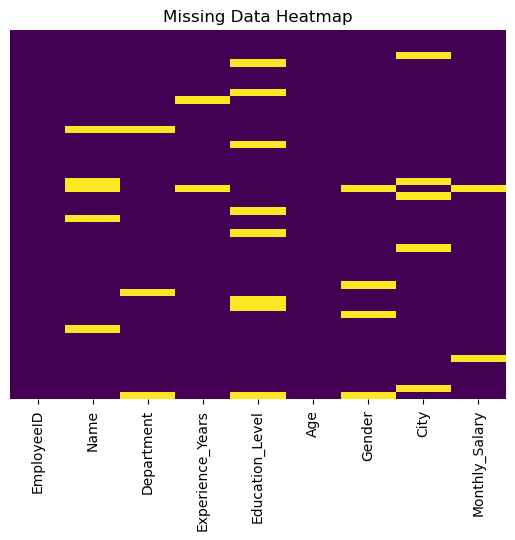

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()

In [4]:
df = df.dropna(subset=['Experience_Years'])

In [5]:
# Fill salary with mean
df['Monthly_Salary'].fillna(df['Monthly_Salary'].mean(), inplace=True)

# Fill experience with median
df['Experience_Years'].fillna(df['Experience_Years'].median(), inplace=True)

C:\Users\dhruv\AppData\Local\Temp\ipykernel_17328\2360336617.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Monthly_Salary'].fillna(df['Monthly_Salary'].mean(), inplace=True)
C:\Users\dhruv\AppData\Local\Temp\ipykernel_17328\2360336617.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

In [6]:
df['Education_Level'].fillna(df['Education_Level'].mode()[0], inplace=True)
df['City'].fillna(df['City'].mode()[0], inplace=True)
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)

C:\Users\dhruv\AppData\Local\Temp\ipykernel_17328\367504914.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Education_Level'].fillna(df['Education_Level'].mode()[0], inplace=True)
C:\Users\dhruv\AppData\Local\Temp\ipykernel_17328\367504914.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always be

In [7]:
Q1 = df['Monthly_Salary'].quantile(0.25)
Q3 = df['Monthly_Salary'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_cleaned = df[
    (df['Monthly_Salary'] >= lower_bound) &
    (df['Monthly_Salary'] <= upper_bound)
]

In [8]:
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(df['Monthly_Salary']))

df_no_outliers = df[z_scores < 3]

In [9]:
# Count duplicates
print(df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

0


In [10]:
# Convert text to lowercase
df['Department'] = df['Department'].str.lower()

# Remove extra spaces
df['Department'] = df['Department'].str.strip()

# Replace inconsistent values
df['Department'].replace({
    "hr": "human resources",
    "it dept": "it"
}, inplace=True)

C:\Users\dhruv\AppData\Local\Temp\ipykernel_17328\2182934352.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Department'].replace({
